# Compare QM9 with MLPR Predictions

This notebook compares a random selection of 10,000 molecules from the QM9 dataset with the predicted HOMO-LUMO gap values from a trained MLP Regressor model.

The steps are:
1. Load the QM9 dataset.
2. Select a random sample of 10,000 molecules.
3. Calculate molecular descriptors for the sample.
4. Load the pre-trained MLPR model.
5. Predict the HOMO-LUMO gap for the sample.
6. Create a scatter plot to compare the QM9 `gap` values with the predicted values.

In [2]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.ML.Descriptors import MoleculeDescriptors
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from joblib import load
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [3]:
def canonicalize_smiles(smiles: str) -> str | None:
    """
    Converts a SMILES string to its canonical form using RDKit.

    Args:
        smiles: The input SMILES string.

    Returns:
        The canonical SMILES string, or None if the input is invalid.
    """
    # Add this check at the beginning to handle None inputs gracefully
    if smiles is None:
        return None

    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return None
        return Chem.MolToSmiles(mol)
    except Exception:
        return None


def is_canonical(smiles: str) -> bool:
    """
    Checks if a SMILES string is canonical using RDKit.

    Args:
        smiles: The input SMILES string to check.

    Returns:
        True if the SMILES is canonical, False otherwise.
        Returns False if the SMILES is invalid.
    """
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        # The input SMILES is invalid
        return False

    # Generate the canonical SMILES from the molecule object
    canonical_smiles = Chem.MolToSmiles(mol)

    # Compare the input with the canonical version
    return smiles == canonical_smiles


def remove_stereochemistry(smiles: str) -> str | None:
    """
    Parses a SMILES string and returns its canonical, achiral form.
    Includes error handling to return None if any step fails.
    """
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return None
        # This single call generates the canonical SMILES of the achiral graph
        return Chem.MolToSmiles(mol, isomericSmiles=False)
    except Exception:
        return None

## 1. Load QM9 Dataset

In [4]:
from pathlib import Path

data_dir = Path("../data/processed")
csv_path = data_dir / "df_qm9.csv"
pkl_path = data_dir / "df_qm9.pkl"

if csv_path.exists():
    try:
        df_qm9 = pd.read_csv(csv_path)
        print(f"QM9 DataFrame loaded from CSV: {csv_path}")
        # print(df_qm9.head())
    except Exception as e:
        print(f"Failed to read CSV {csv_path}: {e}")
        raise
elif pkl_path.exists():
    try:
        # Loading pickles can be unsafe for untrusted sources.
        # Only load if you trust the file origin.
        df_qm9 = pd.read_pickle(pkl_path)
        print(f"QM9 DataFrame loaded from pickle: {pkl_path}")
        print(df_qm9.head())
    except Exception as e:
        print(f"Failed to read pickle {pkl_path}: {e}")
        raise
else:
    print(
        f"Error: Neither {csv_path} nor {pkl_path} was found. Please ensure the file is generated by 'compare_to_datasets.ipynb'."
    )
    raise FileNotFoundError(f"Neither {csv_path} nor {pkl_path} exists.")

QM9 DataFrame loaded from CSV: ../data/processed/df_qm9.csv


In [5]:
df_qm9

,idx,mu,alpha,homo,lumo,gap,r2,zpve,U0,U,...,U0_atom,U_atom,H_atom,G_atom,A,B,C,smiles,achiralSmiles,canonicalSmiles
0,0,0.0000,13.21,-10.549854,3.186453,13.736308,35.3641,1.217682,-1101.4878,-1101.4098,...,-17.172182,-17.286823,-17.389656,-16.151918,157.71180,157.709980,157.706990,[H]C([H])([H])[H],C,C
1,1,1.6256,9.46,-6.993326,2.255824,9.249149,26.1563,0.934929,-1538.1477,-1538.0698,...,-12.005855,-12.082129,-12.159273,-11.246005,293.60974,293.541100,191.393970,[H]N([H])[H],N,N
2,2,1.8511,6.31,-7.967494,1.869422,9.836916,19.0002,0.581643,-2079.0780,-2079.0007,...,-9.240362,-9.278811,-9.330214,-8.733849,799.58813,437.903870,282.945470,[H]O[H],O,O
3,3,0.0000,16.28,-7.741639,1.376896,9.118535,59.5248,0.730381,-2103.6694,-2103.5906,...,-16.716963,-16.792230,-16.869347,-15.862634,0.00000,35.610035,35.610035,[H]C#C[H],C#C,C#C
4,4,2.8937,12.99,-9.806983,0.519737,10.329442,48.7476,0.451736,-2541.8670,-2541.7983,...,-13.088188,-13.135290,-13.186666,-12.520096,0.00000,44.593884,44.593884,[H]C#N,C#N,C#N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
130826,133880,1.6637,69.37,-6.133446,1.600029,7.733476,760.7472,3.466894,-10901.8030,-10901.6590,...,-69.555380,-70.028700,-70.414180,-64.734830,3.59483,2.198990,1.904230,[H]C1([H])[C@@]2([H])[N@@H+]3[C@@]2([H])[C@@]2...,NaN,NaN
130827,133881,1.2976,69.52,-6.511684,1.654452,8.168858,762.6354,3.469316,-10901.6890,-10901.5470,...,-69.442320,-69.915634,-70.301140,-64.621740,3.65648,2.142370,1.904390,[H]C1([H])[N@@H+]2[C@@]3([H])[C@]2([H])[C@]2([...,NaN,NaN
130828,133882,1.2480,73.60,-6.076302,1.959220,8.035522,780.3553,3.822057,-10360.8420,-10360.6970,...,-72.289990,-72.801025,-73.212240,-67.177280,3.67118,2.143140,1.895010,[H]C1([H])[N@@H+]2[C@@]3([H])[C@]2([H])[C@]2([...,C1[NH+]2C3C2C2[NH+]4CC12C34,C1[NH+]2C3C2C2[NH+]4CC12C34
130829,133883,1.9576,77.40,-5.774256,2.397323,8.171579,803.1904,4.142171,-9924.5470,-9924.3990,...,-77.821304,-78.368140,-78.805080,-72.433290,3.52845,2.151310,1.865820,[H]C1([H])[N@H+]2[C@@]3([H])[C@@]14C([H])([H])...,C1C2C3C2C2[NH+]4CC12C34,C1C2C3C2C2[NH+]4CC12C34


In [6]:
df_qm9.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 130831 entries, 0 to 130830
Data columns (total 23 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   idx              130831 non-null  int64  
 1   mu               130831 non-null  float64
 2   alpha            130831 non-null  float64
 3   homo             130831 non-null  float64
 4   lumo             130831 non-null  float64
 5   gap              130831 non-null  float64
 6   r2               130831 non-null  float64
 7   zpve             130831 non-null  float64
 8   U0               130831 non-null  float64
 9   U                130831 non-null  float64
 10  H                130831 non-null  float64
 11  G                130831 non-null  float64
 12  Cv               130831 non-null  float64
 13  U0_atom          130831 non-null  float64
 14  U_atom           130831 non-null  float64
 15  H_atom           130831 non-null  float64
 16  G_atom           130831 non-null  floa

## 2. Select Random Sample (10,000 molecules)

In [ ]:
sample_size = 130831  # 130831 means all
if len(df_qm9) > sample_size:
    df_qm9_sample = df_qm9.sample(n=sample_size, random_state=42).copy()
    print(f"Selected a random sample of {sample_size} molecules.")
else:
    df_qm9_sample = df_qm9.copy()
    print(
        f"QM9 dataset has {len(df_qm9)} molecules, which is less than the requested sample size. Using the entire dataset."
    )

print(f"Sampled DataFrame shape: {df_qm9_sample.shape}")
df_qm9_sample

QM9 dataset has 130831 molecules, which is less than the requested sample size. Using the entire dataset.
Sampled DataFrame shape: (130831, 23)
   idx      mu  alpha       homo      lumo        gap       r2      zpve  \
0    0  0.0000  13.21 -10.549854  3.186453  13.736308  35.3641  1.217682   
1    1  1.6256   9.46  -6.993326  2.255824   9.249149  26.1563  0.934929   
2    2  1.8511   6.31  -7.967494  1.869422   9.836916  19.0002  0.581643   
3    3  0.0000  16.28  -7.741639  1.376896   9.118535  59.5248  0.730381   
4    4  2.8937  12.99  -9.806983  0.519737  10.329442  48.7476  0.451736   

          U0          U  ...    U0_atom     U_atom     H_atom     G_atom  \
0 -1101.4878 -1101.4098  ... -17.172182 -17.286823 -17.389656 -16.151918   
1 -1538.1477 -1538.0698  ... -12.005855 -12.082129 -12.159273 -11.246005   
2 -2079.0780 -2079.0007  ...  -9.240362  -9.278811  -9.330214  -8.733849   
3 -2103.6694 -2103.5906  ... -16.716963 -16.792230 -16.869347 -15.862634   
4 -2541.8670 -2541.

## 3. Calculate Descriptors

In [8]:
from pathlib import Path

pkl_path = Path("../data/processed/calc_descriptors_final.pkl")
try:
    df_descr_template = pd.read_pickle(pkl_path)
    descriptor_names = list(df_descr_template.columns)
    print(f"Loaded {len(descriptor_names)} descriptor names from {pkl_path}")
    # show a short preview
    print(descriptor_names)
except FileNotFoundError:
    descriptor_names = None
    print(
        f"Error: {pkl_path} not found. Make sure you generated it in 'compare_to_datasets.ipynb'."
    )
except Exception as e:
    descriptor_names = None
    print(f"Failed to load descriptors template: {e}")


Loaded 56 descriptor names from ../data/processed/calc_descriptors_final.pkl
['MaxAbsEStateIndex', 'MinAbsEStateIndex', 'MinEStateIndex', 'SPS', 'MolWt', 'NumRadicalElectrons', 'AvgIpc', 'BalabanJ', 'HallKierAlpha', 'Ipc', 'PEOE_VSA11', 'PEOE_VSA12', 'PEOE_VSA13', 'PEOE_VSA14', 'PEOE_VSA2', 'PEOE_VSA3', 'PEOE_VSA4', 'PEOE_VSA5', 'PEOE_VSA6', 'PEOE_VSA7', 'SMR_VSA10', 'SMR_VSA3', 'SMR_VSA4', 'SMR_VSA6', 'SMR_VSA7', 'SMR_VSA9', 'SlogP_VSA1', 'SlogP_VSA10', 'SlogP_VSA12', 'SlogP_VSA7', 'SlogP_VSA8', 'EState_VSA11', 'EState_VSA2', 'EState_VSA3', 'EState_VSA4', 'EState_VSA5', 'EState_VSA6', 'VSA_EState10', 'VSA_EState6', 'NumAliphaticHeterocycles', 'NumAromaticCarbocycles', 'NumAromaticHeterocycles', 'MolLogP', 'fr_Al_COO', 'fr_Al_OH_noTert', 'fr_Ar_N', 'fr_NH0', 'fr_NH2', 'fr_allylic_oxid', 'fr_aniline', 'fr_aryl_methyl', 'fr_bicyclic', 'fr_ester', 'fr_ketone', 'fr_para_hydroxylation', 'fr_piperdine']


In [9]:
compare_features = [
    "MaxAbsEStateIndex",
    "MinAbsEStateIndex",
    "MinEStateIndex",
    "SPS",
    "MolWt",
    "NumRadicalElectrons",
    "AvgIpc",
    "BalabanJ",
    "HallKierAlpha",
    "Ipc",
    "PEOE_VSA11",
    "PEOE_VSA12",
    "PEOE_VSA13",
    "PEOE_VSA14",
    "PEOE_VSA2",
    "PEOE_VSA3",
    "PEOE_VSA4",
    "PEOE_VSA5",
    "PEOE_VSA6",
    "PEOE_VSA7",
    "SMR_VSA10",
    "SMR_VSA3",
    "SMR_VSA4",
    "SMR_VSA6",
    "SMR_VSA7",
    "SMR_VSA9",
    "SlogP_VSA1",
    "SlogP_VSA10",
    "SlogP_VSA12",
    "SlogP_VSA7",
    "SlogP_VSA8",
    "EState_VSA11",
    "EState_VSA2",
    "EState_VSA3",
    "EState_VSA4",
    "EState_VSA5",
    "EState_VSA6",
    "VSA_EState10",
    "VSA_EState6",
    "NumAliphaticHeterocycles",
    "NumAromaticCarbocycles",
    "NumAromaticHeterocycles",
    "MolLogP",
    "fr_Al_COO",
    "fr_Al_OH_noTert",
    "fr_Ar_N",
    "fr_NH0",
    "fr_NH2",
    "fr_allylic_oxid",
    "fr_aniline",
    "fr_aryl_methyl",
    "fr_bicyclic",
    "fr_ester",
    "fr_ketone",
    "fr_para_hydroxylation",
    "fr_piperdine",
]

l = [(i, j) for i, j in zip(descriptor_names, compare_features) if i == j]

In [10]:
def RDkit_descriptors(smiles_series, descriptor_names=None):
    """
    Calculate RDKit descriptors for a series of SMILES.

    If `descriptor_names` is provided it will be used as the list of
    descriptor names to compute (preserves order). Otherwise the full
    RDKit descriptor list will be used.
    """
    # Determine which descriptor names to compute
    if descriptor_names is None:
        names_to_use = [x[0] for x in descriptor_names]
        print(
            f"No descriptor_names provided — computing full RDKit list ({len(names_to_use)})"
        )
    else:
        names_to_use = list(descriptor_names)
        print(f"Computing {len(names_to_use)} descriptors from provided template")

    # Create the RDKit calculator with the chosen names
    calc = MoleculeDescriptors.MolecularDescriptorCalculator(names_to_use)
    desc_names = calc.GetDescriptorNames()

    Mol_descriptors = []
    for smi in smiles_series:
        mol = Chem.MolFromSmiles(smi)
        if mol is not None:
            try:
                mol_h = Chem.AddHs(mol)
                descriptors = calc.CalcDescriptors(mol_h)
                Mol_descriptors.append(descriptors)
            except Exception:
                # If calculation fails for a molecule, append NaNs
                Mol_descriptors.append([np.nan] * len(desc_names))
        else:
            Mol_descriptors.append([np.nan] * len(desc_names))

    return pd.DataFrame(Mol_descriptors, columns=desc_names)


# Use the extracted descriptor_names if available; otherwise fall back
print("Calculating RDKit descriptors for the QM9 sample (template-aware)...")
try:
    df_qm9_descriptors = RDkit_descriptors(
        df_qm9_sample["smiles"],
        descriptor_names=descriptor_names,
    )
    print("Descriptors calculated.")
    print(df_qm9_descriptors.head())
except NameError as e:
    print("Error: required variables not defined in the notebook kernel —", e)
    raise
except Exception as e:
    print("Descriptor calculation failed:", e)
    raise

Calculating RDKit descriptors for the QM9 sample (template-aware)...
Computing 56 descriptors from provided template


[08:10:14] Explicit valence for atom # 1 C, 5, is greater than permitted
[08:10:15] Explicit valence for atom # 1 C, 5, is greater than permitted
[08:10:15] Explicit valence for atom # 2 C, 5, is greater than permitted
[08:10:15] Explicit valence for atom # 2 C, 5, is greater than permitted
[08:10:15] Explicit valence for atom # 2 C, 5, is greater than permitted
[08:10:15] Explicit valence for atom # 2 C, 5, is greater than permitted
[08:10:15] Explicit valence for atom # 1 C, 5, is greater than permitted
[08:10:16] Explicit valence for atom # 2 C, 5, is greater than permitted
[08:10:16] Explicit valence for atom # 2 C, 5, is greater than permitted
[08:10:16] Explicit valence for atom # 1 C, 5, is greater than permitted
[08:10:16] Explicit valence for atom # 2 C, 5, is greater than permitted
[08:10:16] Explicit valence for atom # 2 C, 5, is greater than permitted
[08:10:16] Explicit valence for atom # 2 C, 5, is greater than permitted
[08:10:17] Explicit valence for atom # 3 C, 5, is g

Descriptors calculated.
   MaxAbsEStateIndex  MinAbsEStateIndex  MinEStateIndex    SPS   MolWt  \
0           5.937500           2.500000       -2.500000  777.0  16.043   
1           5.750000           0.250000       -0.250000  777.0  17.031   
2           5.375000           2.750000        2.750000  777.0  18.015   
3           5.902778           1.597222        1.597222  777.0  26.038   
4           6.986111           1.000000        1.000000  777.0  27.026   

   NumRadicalElectrons  AvgIpc  BalabanJ  HallKierAlpha       Ipc  ...  \
0                  0.0   777.0  3.023716           0.00  3.609640  ...   
1                  0.0   777.0  2.323790          -0.04  3.245112  ...   
2                  0.0   777.0  1.632993          -0.04  2.754888  ...   
3                  0.0   777.0  2.825840          -0.44  6.854753  ...   
4                  0.0   777.0  2.475534          -0.51  2.754888  ...   

   fr_NH0  fr_NH2  fr_allylic_oxid  fr_aniline  fr_aryl_methyl  fr_bicyclic  \
0     0

## 4. Prediction

In [11]:
#
out_dir = Path("../data/processed")
out_dir.mkdir(parents=True, exist_ok=True)

# Merge descriptors into the sample
if "df_qm9_descriptors" in globals():
    # Ensure index alignment if any
    df_qm9_sample_reset = df_qm9_sample.reset_index(drop=True)
    df_qm9_descriptors_reset = df_qm9_descriptors.reset_index(drop=True)
    df_qm9_aug = pd.concat([df_qm9_sample_reset, df_qm9_descriptors_reset], axis=1)
    print(f"Merged descriptors: {df_qm9_aug.shape}")
else:
    raise NameError(
        "df_qm9_descriptors not found. Run descriptor calculation cells first."
    )

df_qm9_aug

Merged descriptors: (130831, 79)


,idx,mu,alpha,homo,lumo,gap,r2,zpve,U0,U,...,fr_NH0,fr_NH2,fr_allylic_oxid,fr_aniline,fr_aryl_methyl,fr_bicyclic,fr_ester,fr_ketone,fr_para_hydroxylation,fr_piperdine
0,0,0.0000,13.21,-10.549854,3.186453,13.736308,35.3641,1.217682,-1101.4878,-1101.4098,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,1.6256,9.46,-6.993326,2.255824,9.249149,26.1563,0.934929,-1538.1477,-1538.0698,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,1.8511,6.31,-7.967494,1.869422,9.836916,19.0002,0.581643,-2079.0780,-2079.0007,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,3,0.0000,16.28,-7.741639,1.376896,9.118535,59.5248,0.730381,-2103.6694,-2103.5906,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,4,2.8937,12.99,-9.806983,0.519737,10.329442,48.7476,0.451736,-2541.8670,-2541.7983,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
130826,133880,1.6637,69.37,-6.133446,1.600029,7.733476,760.7472,3.466894,-10901.8030,-10901.6590,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
130827,133881,1.2976,69.52,-6.511684,1.654452,8.168858,762.6354,3.469316,-10901.6890,-10901.5470,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
130828,133882,1.2480,73.60,-6.076302,1.959220,8.035522,780.3553,3.822057,-10360.8420,-10360.6970,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0
130829,133883,1.9576,77.40,-5.774256,2.397323,8.171579,803.1904,4.142171,-9924.5470,-9924.3990,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [12]:
# Load training descriptor template to get column order and the 'Ipc' handling
pkl_template = out_dir / "calc_descriptors_final.pkl"
if pkl_template.exists():
    X_tmp = pd.read_pickle(pkl_template)
    feature_columns = list(X_tmp.columns)
    print(f"Using training feature template with {len(feature_columns)} columns")
else:
    raise FileNotFoundError(f"Training descriptor template not found at {pkl_template}")
# print(feature_columns)

Using training feature template with 56 columns


In [13]:
X_sample = df_qm9_aug[feature_columns].copy()
X_sample.replace([np.inf, -np.inf], np.nan, inplace=True)
X_sample = X_sample.dropna(axis="rows")
zero_cols = X_sample.columns[(X_sample == 0).all()]
# X_sample.drop(labels=zero_cols, axis=1, inplace=True)
print(zero_cols)
# Apply the same scaling used in training
scaler = MinMaxScaler()
# Use .loc to prevent a potential SettingWithCopyWarning
X_sample.loc[:, "Ipc"] = scaler.fit_transform(X_sample["Ipc"].values.reshape(-1, 1))

ss = StandardScaler()
# Fit StandardScaler on training features for consistency
# This will now work because X_sample has no NaNs
X_sample_scaled = ss.fit_transform(X_sample)

print(X_sample_scaled.shape)

X_sample

Index(['SlogP_VSA12', 'EState_VSA11', 'VSA_EState10'], dtype='object')
(129428, 56)


/tmp/ipykernel_716687/960823768.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[[4.84126007e-06]
 [2.77659952e-06]
 [0.00000000e+00]
 ...
 [7.91491351e-02]
 [7.91491351e-02]
 [3.63878200e-02]]' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  X_sample.loc[:, "Ipc"] = scaler.fit_transform(X_sample["Ipc"].values.reshape(-1, 1))


,MaxAbsEStateIndex,MinAbsEStateIndex,MinEStateIndex,SPS,MolWt,NumRadicalElectrons,AvgIpc,BalabanJ,HallKierAlpha,Ipc,...,fr_NH0,fr_NH2,fr_allylic_oxid,fr_aniline,fr_aryl_methyl,fr_bicyclic,fr_ester,fr_ketone,fr_para_hydroxylation,fr_piperdine
0,5.937500,2.500000,-2.500000,777.0,16.043,0.0,777.0,3.023716,0.00,0.000005,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,5.750000,0.250000,-0.250000,777.0,17.031,0.0,777.0,2.323790,-0.04,0.000003,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,5.375000,2.750000,2.750000,777.0,18.015,0.0,777.0,1.632993,-0.04,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,5.902778,1.597222,1.597222,777.0,26.038,0.0,777.0,2.825840,-0.44,0.000023,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,6.986111,1.000000,1.000000,777.0,27.026,0.0,777.0,2.475534,-0.51,0.000000,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
130824,8.343750,1.357639,-2.625694,777.0,120.175,0.0,777.0,2.017227,-0.04,0.079149,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0
130825,8.218750,1.916667,-2.210417,777.0,120.151,0.0,777.0,1.966972,-0.04,0.036388,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
130828,8.315972,1.501597,-2.676042,777.0,122.171,0.0,777.0,2.017227,-0.08,0.079149,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0
130829,8.331597,1.485972,-2.613542,777.0,120.175,0.0,777.0,2.017227,-0.04,0.079149,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [14]:
# --- Load the trained model ---
try:
    reg = load("../data/processed/reg_NN_MLP.joblib")
    # reg = load("../data/processed/reg_RF.joblib")
except FileNotFoundError:
    print("Error: '../data/processed/reg_NN_MLP.joblib' not found.")
    exit()

In [15]:
gap_pred = reg.predict(X_sample_scaled)

df_plot = X_sample.copy()
df_plot["gap_predicted_mlpr"] = gap_pred
df_plot = df_plot.join(df_qm9_aug["gap"])
df_plot

,MaxAbsEStateIndex,MinAbsEStateIndex,MinEStateIndex,SPS,MolWt,NumRadicalElectrons,AvgIpc,BalabanJ,HallKierAlpha,Ipc,...,fr_allylic_oxid,fr_aniline,fr_aryl_methyl,fr_bicyclic,fr_ester,fr_ketone,fr_para_hydroxylation,fr_piperdine,gap_predicted_mlpr,gap
0,5.937500,2.500000,-2.500000,777.0,16.043,0.0,777.0,3.023716,0.00,0.000005,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.323954,13.736308
1,5.750000,0.250000,-0.250000,777.0,17.031,0.0,777.0,2.323790,-0.04,0.000003,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.183693,9.249149
2,5.375000,2.750000,2.750000,777.0,18.015,0.0,777.0,1.632993,-0.04,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.095452,9.836916
3,5.902778,1.597222,1.597222,777.0,26.038,0.0,777.0,2.825840,-0.44,0.000023,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.820060,9.118535
4,6.986111,1.000000,1.000000,777.0,27.026,0.0,777.0,2.475534,-0.51,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.335343,10.329442
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
130824,8.343750,1.357639,-2.625694,777.0,120.175,0.0,777.0,2.017227,-0.04,0.079149,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,1.259818,8.723970
130825,8.218750,1.916667,-2.210417,777.0,120.151,0.0,777.0,1.966972,-0.04,0.036388,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.806962,9.064113
130828,8.315972,1.501597,-2.676042,777.0,122.171,0.0,777.0,2.017227,-0.08,0.079149,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,2.395094,8.035522
130829,8.331597,1.485972,-2.613542,777.0,120.175,0.0,777.0,2.017227,-0.04,0.079149,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.971687,8.171579


Saved comparison heatmap to xtb_qm9_comparison_heatmap.png


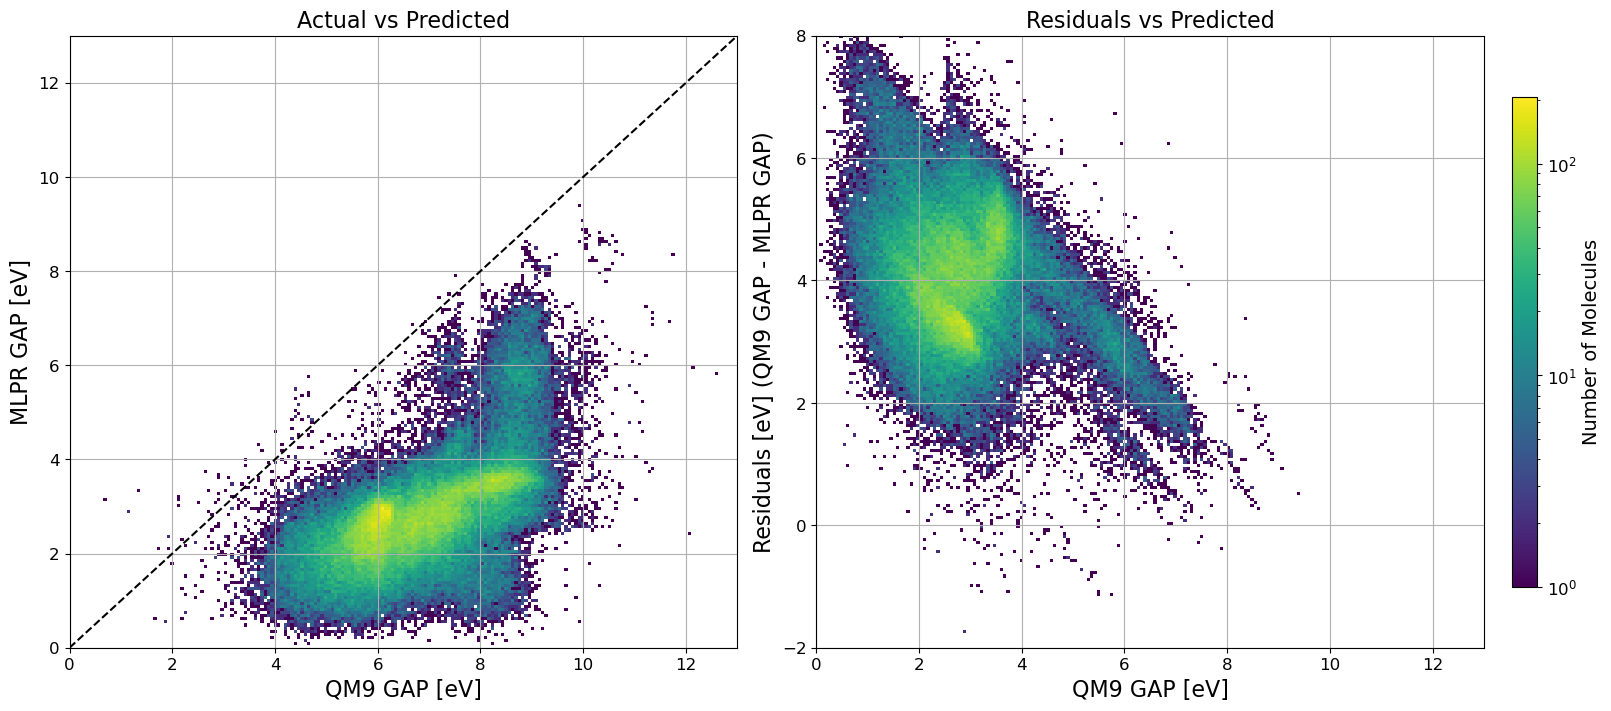

In [23]:
# --- 2D density plots (Actual vs Predicted) like in general_analysis_MLPR.ipynb ---
from matplotlib.colors import LogNorm

# Select rows with both true and predicted values

x = df_plot["gap"].to_numpy()
y = df_plot["gap_predicted_mlpr"].to_numpy()
residuals = x - y

# 2D histograms
bins = 200
heatmap1, xedges1, yedges1 = np.histogram2d(
    x,
    y,
    bins=bins,
    range=[[0, 13], [0, 13]],
    density=False,
)
heatmap2, xedges2, yedges2 = np.histogram2d(
    y,
    residuals,
    bins=bins,
    range=[[0, 13], [-2, 8]],
    density=False,
)

# Determine shared color scale (avoid zeros for LogNorm)
pos_vals1 = heatmap1[heatmap1 > 0]
pos_vals2 = heatmap2[heatmap2 > 0]
all_pos = np.concatenate(
    [
        pos_vals1.flatten() if pos_vals1.size else np.array([1]),
        pos_vals2.flatten() if pos_vals2.size else np.array([1]),
    ]
)

vmin = max(float(all_pos.min()), 1.0)
vmax = float(max(heatmap1.max(), heatmap2.max()))

fig, axs = plt.subplots(1, 2, figsize=(16, 7), constrained_layout=True)

im1 = axs[0].imshow(
    heatmap1.T,
    extent=[xedges1[0], xedges1[-1], yedges1[0], yedges1[-1]],
    origin="lower",
    cmap="viridis",
    aspect="auto",
    norm=LogNorm(vmin=vmin, vmax=vmax),
)
axs[0].set_xlim(0, 13)
axs[0].set_ylim(0, 13)
axs[0].grid()
axs[0].tick_params(axis="both", which="major", labelsize=12)
axs[0].set_xlabel("QM9 GAP [eV]", fontsize=16)
axs[0].set_ylabel("MLPR GAP [eV]", fontsize=16)
axs[0].set_title("Actual vs Predicted", fontsize=16)
axs[0].plot([0, 13], [0, 13], "k--")  # Add x=y line

im2 = axs[1].imshow(
    heatmap2.T,
    extent=[xedges2[0], xedges2[-1], yedges2[0], yedges2[-1]],
    origin="lower",
    cmap="viridis",
    aspect="auto",
    norm=LogNorm(vmin=vmin, vmax=vmax),
)
axs[1].set_xlim(0, 13)
axs[1].set_ylim(-2, 8)
axs[1].grid()
axs[1].tick_params(axis="both", which="major", labelsize=12)
axs[1].set_xlabel("QM9 GAP [eV]", fontsize=16)
axs[1].set_ylabel("Residuals [eV] (QM9 GAP - MLPR GAP)", fontsize=16)
axs[1].set_title("Residuals vs Predicted", fontsize=16)

# Add a single colorbar for both plots
cbar = fig.colorbar(im1, ax=axs, orientation="vertical", shrink=0.8, pad=0.02)
cbar.set_label("Number of Molecules", fontsize=14)
cbar.ax.tick_params(labelsize=12)

# Save and show
out_dir = Path("./")
fig_path = out_dir / "xtb_qm9_comparison_heatmap.png"
plt.savefig(fig_path, dpi=300)
print(f"Saved comparison heatmap to {fig_path}")
plt.show()

In [19]:
plt.clf()

<Figure size 640x480 with 0 Axes>